<a href="https://colab.research.google.com/github/syedmahmoodiagents/pytorch/blob/main/Pytorch_NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# pip install scikit-learn

In [1]:
from sklearn.datasets import make_regression

In [2]:
X, Y = make_regression(n_features=6, n_informative=3)

In [3]:
X.shape

(100, 6)

In [4]:
Y.shape

(100,)

In [9]:
import torch
import torch.nn as nn

In [10]:
X = torch.FloatTensor(X)

In [12]:
Y = torch.FloatTensor(Y).view(-1, 1)

In [24]:
class NewModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.ln1 = nn.Linear(6, 10)
        self.ln2 = nn.Linear(10, 1)

    def forward(self, x):
        x = self.ln1(x)
        x = self.ln2(x)
        return x

In [25]:
mod = NewModel()

In [26]:
Yp = mod(X)

In [27]:
Yp

tensor([[-0.4934],
        [ 0.3411],
        [ 0.1102],
        [-0.3893],
        [-0.0393],
        [-0.7153],
        [-1.0468],
        [ 0.0134],
        [ 0.2583],
        [-0.4328],
        [-1.0489],
        [-0.5688],
        [-0.3661],
        [ 0.1694],
        [-0.4067],
        [ 0.2054],
        [ 0.3631],
        [-0.2334],
        [-0.4118],
        [ 0.0502],
        [ 0.6337],
        [ 0.2038],
        [-0.3989],
        [ 0.2880],
        [ 0.0713],
        [-0.4750],
        [-0.1445],
        [-0.3319],
        [-0.1405],
        [-0.7492],
        [-0.3048],
        [ 0.5491],
        [ 0.0695],
        [-0.8175],
        [-0.0452],
        [ 0.0332],
        [-0.2624],
        [-0.7141],
        [-0.2903],
        [ 0.3212],
        [-0.5156],
        [-0.4239],
        [ 0.0397],
        [-0.0882],
        [-0.0157],
        [-0.0963],
        [-0.1202],
        [-0.2325],
        [-0.5402],
        [-0.0399],
        [ 0.1219],
        [ 0.2452],
        [-0.

In [28]:
from torch.optim import SGD

In [29]:
lossfn = nn.MSELoss()

In [30]:
opt = SGD(mod.parameters(), lr=0.001)

In [31]:
for k in range(20):
    opt.zero_grad()
    Yp = mod(X)
    loss = lossfn(Yp, Y)
    loss.backward()
    opt.step()
    print(loss)

tensor(2124.7529, grad_fn=<MseLossBackward0>)
tensor(2115.3035, grad_fn=<MseLossBackward0>)
tensor(2106.2207, grad_fn=<MseLossBackward0>)
tensor(2097.2180, grad_fn=<MseLossBackward0>)
tensor(2088.0212, grad_fn=<MseLossBackward0>)
tensor(2078.3601, grad_fn=<MseLossBackward0>)
tensor(2067.9595, grad_fn=<MseLossBackward0>)
tensor(2056.5349, grad_fn=<MseLossBackward0>)
tensor(2043.7820, grad_fn=<MseLossBackward0>)
tensor(2029.3729, grad_fn=<MseLossBackward0>)
tensor(2012.9508, grad_fn=<MseLossBackward0>)
tensor(1994.1239, grad_fn=<MseLossBackward0>)
tensor(1972.4634, grad_fn=<MseLossBackward0>)
tensor(1947.5010, grad_fn=<MseLossBackward0>)
tensor(1918.7297, grad_fn=<MseLossBackward0>)
tensor(1885.6101, grad_fn=<MseLossBackward0>)
tensor(1847.5769, grad_fn=<MseLossBackward0>)
tensor(1804.0557, grad_fn=<MseLossBackward0>)
tensor(1754.4854, grad_fn=<MseLossBackward0>)
tensor(1698.3489, grad_fn=<MseLossBackward0>)


for non linear data

In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [56]:
import torch
import torch.nn as nn
from torch.optim import SGD

In [66]:
x = np.linspace(-2,3,21)

In [67]:
np.random.seed(3)
y = np.sin(x) + np.random.normal(0,0.2,21)

In [68]:
y = y.round(2)

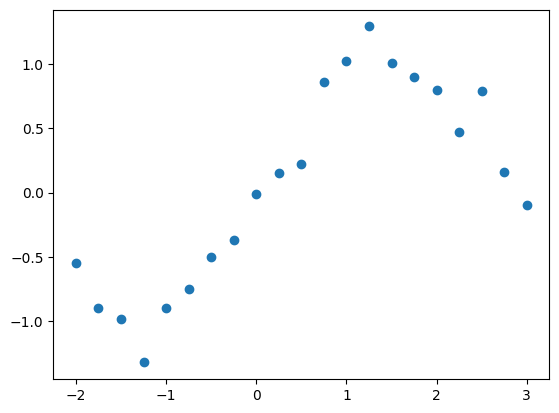

In [69]:
plt.scatter(x,y)

In [121]:
X = torch.FloatTensor(x).view(-1,1)
Y = torch.FloatTensor(y).view(-1,1)

In [196]:
class SecondModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.ln1 = nn.Linear(1, 8)
        self.ln2 = nn.Linear(8, 8)
        self.ln3 = nn.Linear(8, 8)
        self.ln4 = nn.Linear(8, 1)
        self.rl = nn.ReLU()

    def forward(self, x):
        x = self.ln1(x)
        x = self.rl(x)
        x = self.ln2(x)
        x = self.rl(x)
        x = self.ln3(x)
        x = self.rl(x)
        x = self.ln4(x)
        return x

In [197]:
mmodl = SecondModel()

In [198]:
lossf = nn.MSELoss()
op = SGD(mmodl.parameters(), lr=0.1)

In [199]:
for k in range(300):
    op.zero_grad()
    Yp = mmodl(X)
    loss = lossf(Yp, Y)
    loss.backward()
    op.step()
    # print(loss)

In [200]:
Yp = mmodl(X)

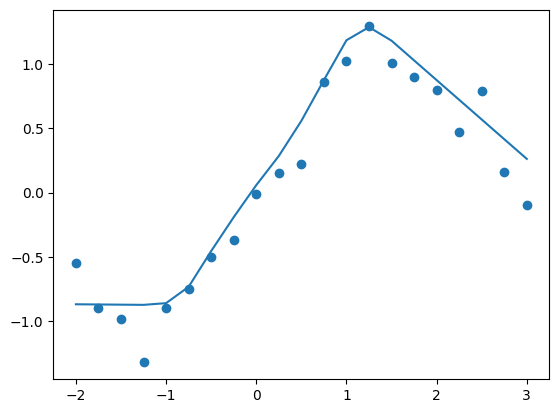

In [201]:
plt.scatter(x,y)
plt.plot(x,Yp.detach().numpy())

In [202]:
from sklearn.inspection import DecisionBoundaryDisplay